In [1]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    AdaBoostRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

print("Libraries imported successfully!!")

Libraries imported successfully!!


In [4]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Extra Trees": ExtraTreesRegressor(random_state=42),
    "AdaBoost": AdaBoostRegressor(random_state=42),
    "KNN": KNeighborsRegressor(),
    "Support Vector Regressor": SVR()
}

In [10]:
df = pd.read_csv("../data/Feature_Engineered_StudentPerformanceFactors.csv")
df.head(5)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,...,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score,Study_Efficiency,Academic_Engagement,Lifestyle_Score
0,0.504942,0.348375,1.0,0.0,0,-0.019796,-0.143800,1.0,1,-1.213934,...,2,0.031411,0,1.0,2.0,1,67,0.627550,0.426504,0.001856
1,-0.162822,-1.383736,1.0,2.0,0,0.661399,-1.116110,1.0,1,0.411451,...,0,1.001199,0,0.0,1.0,0,61,-0.713283,-1.263077,1.116901
2,0.671882,1.560853,2.0,2.0,1,-0.019796,1.106313,2.0,1,0.411451,...,1,1.001199,0,2.0,2.0,1,74,1.414073,1.732090,0.559379
3,1.506587,0.781403,1.0,2.0,1,0.661399,1.592469,2.0,1,-0.401242,...,0,1.001199,0,1.0,1.0,1,71,1.842914,1.348095,1.116901
4,-0.162822,1.041220,2.0,2.0,1,-0.700990,-0.699406,2.0,1,1.224144,...,1,1.001199,0,0.0,2.0,0,70,0.282978,0.964099,0.001856


In [12]:


X = df.drop('Exam_Score', axis=1)
y = df['Exam_Score']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(5285, 22)
(1322, 22)


In [13]:

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)
    rmse = mean_squared_error(y_test, predictions) ** 0.5
    r2 = r2_score(y_test, predictions)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2
    })

In [14]:
results_df = pd.DataFrame(results)

results_df.sort_values(
    by="R² Score",
    ascending=False
)

,Model,MAE,RMSE,R² Score
7,Support Vector Regressor,0.581030,1.861076,0.754964
3,Gradient Boosting,0.742267,1.894245,0.746152
0,Linear Regression,1.016439,2.096572,0.689028
4,Extra Trees,0.987874,2.111186,0.684678
2,Random Forest,1.058177,2.238806,0.645403
6,KNN,1.380333,2.408809,0.589506
5,AdaBoost,1.849186,2.759541,0.461264
1,Decision Tree,1.625567,3.289717,0.234370


In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVR

params = {
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto", 0.1, 0.01],
    "kernel": ["rbf", "linear"]
}

grid = GridSearchCV(
    SVR(),
    params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'C': 100, 'gamma': 0.01, 'kernel': 'rbf'}
0.7204947389917997


In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    grid.best_estimator_,
    X,
    y,
    cv=10,
    scoring="r2"
)

print(scores)
print(scores.mean())

[0.59691045 0.64498381 0.77783986 0.66983814 0.66905947 0.73899963
 0.66378074 0.82523942 0.98915684 0.72933871]
0.7305147072527711


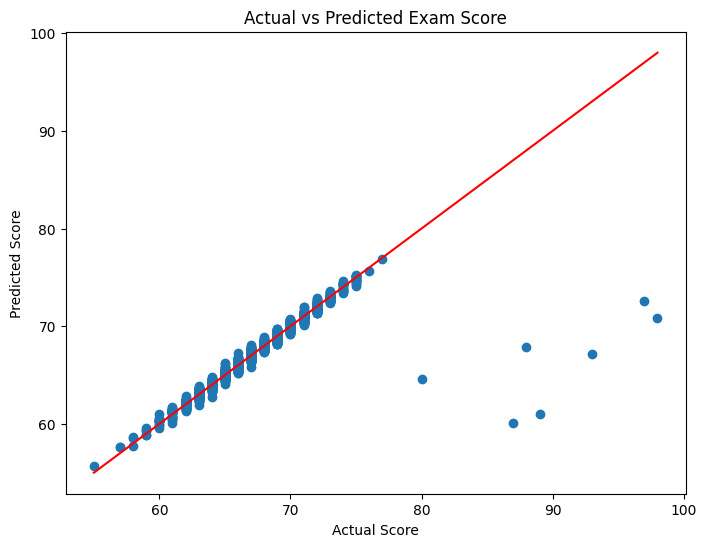

In [ ]:
pred = grid.best_estimator_.predict(X_test)

plt.figure(figsize=(8,6))

plt.scatter(y_test, pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted Exam Score")

plt.show()

In [ ]:
rf = RandomForestRegressor(random_state=42)

rf.fit(X_train, y_train)

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                       Feature  Importance
20         Academic_Engagement    0.563757
6              Previous_Scores    0.077432
19            Study_Efficiency    0.051012
3          Access_to_Resources    0.030421
2         Parental_Involvement    0.028638
1                   Attendance    0.025341
21             Lifestyle_Score    0.024378
0                Hours_Studied    0.022870
9            Tutoring_Sessions    0.021047
14           Physical_Activity    0.020291
5                  Sleep_Hours    0.017193
10               Family_Income    0.017058
17          Distance_from_Home    0.016098
13              Peer_Influence    0.014622
16    Parental_Education_Level    0.014489
7             Motivation_Level    0.011747
11             Teacher_Quality    0.011573
4   Extracurricular_Activities    0.008283
15       Learning_Disabilities    0.007824
8              Internet_Access    0.005843
12                 School_Type    0.005304
18                      Gender    0.004779


In [15]:
import pickle

In [17]:
from sklearn.svm import SVR

svr = SVR()

svr.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [19]:
with open("student_performance_model.pkl", "wb") as file:
    pickle.dump(svr, file)